# SABR Calibration and Delta Hedging Analysis on AAPL Options

This project calibrates a **SABR stochastic volatility model** to an observed AAPL option implied volatility smile, then evaluates the impact of **model misspecification** on delta hedging performance.

## Objectives
- Extract a market implied volatility smile from live AAPL option data
- Calibrate SABR parameters using the Hagan lognormal approximation
- Simulate forward price paths under SABR dynamics
- Compare hedging P&L under:
  - correctly calibrated SABR delta
  - miscalibrated SABR delta
  - Black-Scholes ATM constant-vol delta

## Motivation
In quantitative trading and derivatives modeling, pricing accuracy is important, but **hedging robustness** is often even more important. This notebook demonstrates how volatility model calibration affects hedging error distributions in practice.

## Models used
- **Black-76** for implied volatility inversion and delta computation
- **SABR model** for smile dynamics
- **Monte Carlo simulation** for terminal option pricing and hedge P&L analysis

## 1. Imports and Environment Setup

We begin by importing the scientific Python stack and optimization/statistics tools required for:
- option pricing
- implied volatility inversion
- SABR calibration
- Monte Carlo simulation
- visualization

The notebook optionally supports live market data through `yfinance`.

In [107]:
import math
import warnings
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import numpy as np
np.set_printoptions(suppress=True, precision=6)

import pandas as pd

from scipy.optimize import brentq, least_squares
from scipy.stats import norm
import matplotlib.pyplot as plt

import yfinance as yf

## 2. Black-76 Utilities

This section implements the core Black-76 tools used throughout the notebook:
- call pricing on forwards
- forward delta
- implied volatility inversion from market prices

These functions are used to transform option chain prices into a tradable implied volatility smile.

In [108]:
def black_call_price(F: float, K: float, T: float, r: float, sigma: float) -> float:
    #Black-76 call price on forward F with discount exp(-rT)
    if T <= 0:
        return max(F - K, 0.0)
    if sigma <= 0:
        return math.exp(-r * T) * max(F - K, 0.0)

    vol_sqrt = sigma * math.sqrt(T)
    if vol_sqrt < 1e-12:
        return math.exp(-r * T) * max(F - K, 0.0)

    lnFK = math.log(F / K)
    d1 = (lnFK + 0.5 * sigma * sigma * T) / vol_sqrt
    d2 = d1 - vol_sqrt
    return math.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def black_call_delta_forward(F: float, K: float, T: float, r: float, sigma: float) -> float:
    if T <= 0:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)
    if sigma <= 0:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)

    vol_sqrt = sigma * math.sqrt(T)
    if vol_sqrt < 1e-12:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)

    lnFK = math.log(F / K)
    d1 = (lnFK + 0.5 * sigma * sigma * T) / vol_sqrt
    return math.exp(-r * T) * norm.cdf(d1)


def implied_vol_black_call(price: float, F: float, K: float, T: float, r: float) -> float:
    if T <= 0:
        return float("nan")

    disc = math.exp(-r * T)
    intrinsic = disc * max(F - K, 0.0)
    upper = disc * F  # arbitrage upper bound for a call on a forward

    if not (intrinsic - 1e-12 <= price <= upper + 1e-12):
        return float("nan")

    def f(sig):
        return black_call_price(F, K, T, r, sig) - price

    try:
        return brentq(f, 1e-8, 5.0, maxiter=200)
    except Exception:
        return float("nan")

## 3. SABR Model and Hagan Lognormal Approximation

The SABR model is widely used to fit implied volatility smiles in rates, FX, and equity derivatives.  
We use the **Hagan et al. lognormal approximation** to map SABR parameters into Black implied volatilities.

### SABR dynamics
\[
dF_t = \alpha_t F_t^\beta dW_t^{(1)}
\]
\[
d\alpha_t = \nu \alpha_t dW_t^{(2)}
\]
with
\[
\mathrm{corr}(dW_t^{(1)}, dW_t^{(2)}) = \rho
\]

### Parameters
- \(\alpha\): initial volatility level
- \(\beta\): elasticity parameter
- \(\rho\): correlation between price and volatility shocks
- \(\nu\): volatility of volatility

We fix \(\beta\) and calibrate \((\alpha, \rho, \nu)\) by least squares against market implied vols.

In [109]:
def sabr_hagan_lognormal_iv(F: float, K: float, T: float,
                            alpha: float, beta: float, rho: float, nu: float) -> float:
    if T <= 0:
        return 0.0
    if F <= 0 or K <= 0 or alpha <= 0:
        return float("nan")

    if abs(F - K) < 1e-12:
        FK_beta = F ** (1.0 - beta)
        term1 = alpha / FK_beta

        A = ((1 - beta) ** 2 / 24.0) * (alpha ** 2) / (F ** (2 - 2 * beta))
        B = (rho * beta * nu * alpha) / (4.0 * (F ** (1 - beta)))
        C = (2 - 3 * rho * rho) * (nu ** 2) / 24.0
        return term1 * (1.0 + (A + B + C) * T)

    lnFK = math.log(F / K)
    one_minus_beta = 1.0 - beta

    FK = F * K
    FK_beta = FK ** (one_minus_beta / 2.0)

    z = (nu / alpha) * FK_beta * lnFK
    sqrt_term = math.sqrt(max(1.0 - 2.0 * rho * z + z * z, 1e-16))
    xz = math.log((sqrt_term + z - rho) / (1.0 - rho))

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * (lnFK ** 2)
        + (one_minus_beta ** 4 / 1920.0) * (lnFK ** 4)
    )

    A = ((one_minus_beta) ** 2 / 24.0) * (alpha ** 2) / (FK ** one_minus_beta)
    B = (rho * beta * nu * alpha) / (4.0 * (FK ** (one_minus_beta / 2.0)))
    C = (2.0 - 3.0 * rho * rho) * (nu ** 2) / 24.0

    if abs(xz) < 1e-14:
        return float("nan")

    sigma = (alpha / denom) * (z / xz) * (1.0 + (A + B + C) * T)
    return max(sigma, 0.0)


def calibrate_sabr_hagan(F: float, T: float, strikes: np.ndarray, market_iv: np.ndarray,
                         beta: float = 0.5,
                         bounds: Tuple[Tuple[float, float, float], Tuple[float, float, float]] = (
                             (1e-6, -0.999, 1e-6), (5.0, 0.999, 5.0)
                         ),
                         x0: Optional[np.ndarray] = None) -> Tuple[float, float, float]:
    strikes = np.asarray(strikes, dtype=float)
    market_iv = np.asarray(market_iv, dtype=float)

    mask = np.isfinite(market_iv) & (market_iv > 1e-6) & np.isfinite(strikes) & (strikes > 0)
    K = strikes[mask]
    iv = market_iv[mask]

    if len(K) < 5:
        raise ValueError("Not enough valid strikes/IVs to calibrate SABR.")

    if x0 is None:
        atm_idx = np.argmin(np.abs(K - F))
        atm_iv = float(iv[atm_idx]) if np.isfinite(iv[atm_idx]) else float(np.nanmean(iv))
        alpha0 = max(1e-3, atm_iv * (F ** (1 - beta)))
        rho0 = 0.0
        nu0 = 0.5
        x0 = np.array([alpha0, rho0, nu0], dtype=float)

    lb, ub = np.array(bounds[0], float), np.array(bounds[1], float)

    def residuals(x):
        a, r, n = x
        model = np.array([sabr_hagan_lognormal_iv(F, k, T, a, beta, r, n) for k in K], dtype=float)
        w = 1.0 / (0.5 + (np.abs(np.log(K / F)) / 0.15))  # extra weight near ATM
        return w * (model - iv)

    res = least_squares(
        residuals,
        x0=x0,
        bounds=(lb, ub),
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-10,
        max_nfev=5000
    )

    a, r, n = res.x
    return float(a), float(r), float(n)

## 4. Monte Carlo Simulation under SABR Dynamics

To study hedging performance, we simulate the forward process under the calibrated SABR model.

The simulation uses:
- Euler discretization
- correlated Brownian shocks
- positivity floors for both the forward and volatility state

This simulated terminal distribution is used both for:
- option premium estimation
- delta hedging P&L analysis

In [110]:
def simulate_sabr_forward_paths(
    F0: float,
    alpha0: float,
    beta: float,
    rho: float,
    nu: float,
    T: float,
    n_steps: int,
    n_paths: int,
    seed: int = 12345
) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = math.sqrt(dt)

    F = np.full((n_paths, n_steps + 1), F0, dtype=float)
    a = np.full((n_paths, n_steps + 1), alpha0, dtype=float)

    z1 = rng.standard_normal(size=(n_paths, n_steps))
    z2 = rng.standard_normal(size=(n_paths, n_steps))
    w1 = z1
    w2 = rho * z1 + math.sqrt(max(1.0 - rho * rho, 0.0)) * z2

    for t in range(n_steps):
        Ft = np.maximum(F[:, t], 1e-12)
        at = np.maximum(a[:, t], 1e-12)

        dF = at * (Ft ** beta) * sqrt_dt * w1[:, t]
        da = nu * at * sqrt_dt * w2[:, t]

        F[:, t + 1] = np.maximum(Ft + dF, 1e-12)
        a[:, t + 1] = np.maximum(at + da, 1e-12)

    return F, a


def sabr_mc_call_price_from_paths(F_T: np.ndarray, K: float, T: float, r: float) -> float:
    payoff = np.maximum(F_T - K, 0.0)
    return float(math.exp(-r * T) * np.mean(payoff))

## 5. Market Data: AAPL Option Chain and Smile Extraction

We fetch one AAPL expiry from Yahoo Finance and construct a market implied volatility smile.

### Data processing steps
1. Pull latest spot price
2. Select an expiry between 20 and 90 days
3. Restrict strikes to a window around spot
4. Compute **mid prices** using bid/ask when available
5. Convert prices into Black implied vols

### Why use the mid price?
The bid-ask midpoint is a practical proxy for the fair tradable option price.  
Using the mid reduces noise relative to using bid or ask alone and is standard in calibration workflows.

In [111]:
@dataclass
class MarketSmile:
    spot: float
    r: float
    T: float
    expiry: str
    strikes: np.ndarray
    call_mid: np.ndarray
    iv_black: np.ndarray
    F0: float
    atm_iv: float


def _pick_expiry_date(ticker: "yf.Ticker", min_days: int = 20, max_days: int = 90) -> str:
    exps = ticker.options
    if not exps:
        raise ValueError("No option expiries returned by yfinance.")

    today = pd.Timestamp.today(tz=None).normalize()
    cand = []
    for e in exps:
        d = pd.Timestamp(e)
        days = (d - today).days
        if min_days <= days <= max_days:
            cand.append((days, e))

    if not cand:
        return exps[0]

    cand.sort(key=lambda x: x[0])
    return cand[0][1]


def load_aapl_smile_from_yfinance(
    symbol: str = "AAPL",
    r: float = 0.04,
    min_days: int = 20,
    max_days: int = 90,
    strike_span: float = 0.25) -> MarketSmile:

    tk = yf.Ticker(symbol)

    hist = tk.history(period="5d")
    if hist.empty:
        raise ValueError("Failed to fetch spot history.")
    spot = float(hist["Close"].iloc[-1])

    expiry = _pick_expiry_date(tk, min_days=min_days, max_days=max_days)
    chain = tk.option_chain(expiry)
    calls = chain.calls.copy()

    lo = (1.0 - strike_span) * spot
    hi = (1.0 + strike_span) * spot
    calls = calls[(calls["strike"] >= lo) & (calls["strike"] <= hi)].copy()
    calls.sort_values("strike", inplace=True)

    if calls.empty:
        raise ValueError("No calls in selected strike range.")

    bid = calls["bid"].to_numpy(dtype=float)
    ask = calls["ask"].to_numpy(dtype=float)
    last = calls["lastPrice"].to_numpy(dtype=float)
    mid = np.where((bid > 0) & (ask > 0), 0.5 * (bid + ask), last)

    today = pd.Timestamp.today(tz=None).normalize()
    exp_ts = pd.Timestamp(expiry)
    days = max((exp_ts - today).days, 1)
    T = days / 365.0

    F0 = spot * math.exp(r * T)  # ignoring dividends

    strikes = calls["strike"].to_numpy(dtype=float)
    iv = np.array(
        [implied_vol_black_call(float(p), F0, float(k), T, r) for p, k in zip(mid, strikes)],
        dtype=float
    )

    atm_idx = int(np.argmin(np.abs(strikes - spot)))
    atm_iv = float(iv[atm_idx]) if np.isfinite(iv[atm_idx]) else float(np.nanmean(iv[np.isfinite(iv)]))

    if not np.isfinite(atm_iv):
        raise ValueError("Could not compute a valid ATM implied vol.")

    return MarketSmile(
        spot=spot,
        r=r,
        T=T,
        expiry=expiry,
        strikes=strikes,
        call_mid=mid,
        iv_black=iv,
        F0=F0,
        atm_iv=atm_iv
    )

## 6. Hedging Experiment Design

We now define the hedging experiment.

We compare three hedge models:
1. **True SABR delta** using the calibrated parameters
2. **Miscalibrated SABR delta** using deliberately perturbed parameters
3. **Black-Scholes ATM delta** using a constant ATM implied vol

This allows us to study how calibration quality affects hedge performance for a short call position.

In [112]:
@dataclass
class HedgeConfig:
    n_paths: int = 20000
    n_steps: int = 30
    seed: int = 7

    strike: Optional[float] = None   # None -> choose ATM strike
    option_type: str = "call"

    mis_alpha_mult: float = 0.85
    mis_rho_shift: float = 0.15
    mis_nu_mult: float = 1.30

## 7. Delta Hedging Engine

The hedging engine:
- simulates true SABR paths
- prices the option via Monte Carlo
- dynamically rebalances hedge positions through time
- records final P&L for each hedge model

### Interpretation
The resulting P&L distributions reveal:
- hedge bias
- hedge dispersion
- tail risk due to model misspecification

In [113]:
def run_hedge_experiment(
    smile: MarketSmile,
    beta: float,
    sabr_true: Tuple[float, float, float],
    sabr_mis: Tuple[float, float, float],
    atm_bs_vol: float,
    cfg: HedgeConfig
) -> Dict[str, np.ndarray]:
    r, T, F0 = float(smile.r), float(smile.T), float(smile.F0)

    if cfg.strike is None:
        K = float(smile.strikes[np.argmin(np.abs(smile.strikes - smile.spot))])
    else:
        K = float(cfg.strike)

    alpha_t, rho_t, nu_t = sabr_true
    alpha_m, rho_m, nu_m = sabr_mis

    F_paths, _ = simulate_sabr_forward_paths(
        F0=F0,
        alpha0=alpha_t,
        beta=beta,
        rho=rho_t,
        nu=nu_t,
        T=T,
        n_steps=cfg.n_steps,
        n_paths=cfg.n_paths,
        seed=cfg.seed
    )

    premium = sabr_mc_call_price_from_paths(F_paths[:, -1], K=K, T=T, r=r)

    def spot_from_forward(Ft: float, tau: float) -> float:
        return Ft * math.exp(-r * tau)

    def delta_sabr(Ft: float, tau: float, alpha: float, rho: float, nu: float) -> float:
        if tau <= 0:
            return 1.0 if Ft > K else 0.0
        iv = sabr_hagan_lognormal_iv(Ft, K, tau, alpha, beta, rho, nu)
        iv = max(iv, 1e-12)
        dF = black_call_delta_forward(Ft, K, tau, r, iv)
        return dF * math.exp(r * tau)

    def delta_bs_atm(Ft: float, tau: float, sigma: float) -> float:
        if tau <= 0:
            return 1.0 if Ft > K else 0.0
        sigma = max(float(sigma), 1e-12)
        dF = black_call_delta_forward(Ft, K, tau, r, sigma)
        return dF * math.exp(r * tau)

    pnl_true = np.zeros(cfg.n_paths, dtype=float)
    pnl_mis = np.zeros(cfg.n_paths, dtype=float)
    pnl_atm = np.zeros(cfg.n_paths, dtype=float)

    dt = T / cfg.n_steps

    for i in range(cfg.n_paths):
        cash_true = premium
        cash_mis = premium
        cash_atm = premium

        pos_true = 0.0
        pos_mis = 0.0
        pos_atm = 0.0

        for step in range(cfg.n_steps):
            t = step * dt
            tau = T - t
            Ft = float(F_paths[i, step])
            St = float(spot_from_forward(Ft, tau))

            cash_true *= math.exp(r * dt)
            cash_mis *= math.exp(r * dt)
            cash_atm *= math.exp(r * dt)

            d_true = delta_sabr(Ft, tau, alpha_t, rho_t, nu_t)
            d_mis = delta_sabr(Ft, tau, alpha_m, rho_m, nu_m)
            d_atm = delta_bs_atm(Ft, tau, atm_bs_vol)

            trade_true = (d_true - pos_true) * St
            trade_mis = (d_mis - pos_mis) * St
            trade_atm = (d_atm - pos_atm) * St

            cash_true -= trade_true
            cash_mis -= trade_mis
            cash_atm -= trade_atm

            pos_true = d_true
            pos_mis = d_mis
            pos_atm = d_atm

        Ft_T = float(F_paths[i, -1])
        St_T = float(spot_from_forward(Ft_T, 0.0))
        payoff = max(Ft_T - K, 0.0)

        cash_true += pos_true * St_T
        cash_mis += pos_mis * St_T
        cash_atm += pos_atm * St_T

        cash_true -= payoff
        cash_mis -= payoff
        cash_atm -= payoff

        pnl_true[i] = cash_true
        pnl_mis[i] = cash_mis
        pnl_atm[i] = cash_atm

    return {
        "premium_mc": np.array([premium]),
        "K": np.array([K]),
        "pnl_sabr_true": pnl_true,
        "pnl_sabr_miscal": pnl_mis,
        "pnl_bs_atm": pnl_atm
    }

## 8. P&L Summary Statistics

To compare hedging methods, we report:
- mean
- standard deviation
- selected tail quantiles

These metrics help distinguish average hedge quality from downside risk.

In [114]:
def summarize_pnl(x: np.ndarray, name: str) -> None:
    x = np.asarray(x, float)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1))
    p01 = float(np.quantile(x, 0.01))
    p05 = float(np.quantile(x, 0.05))
    p50 = float(np.quantile(x, 0.50))
    p95 = float(np.quantile(x, 0.95))
    p99 = float(np.quantile(x, 0.99))

    print(f"\n{name}")
    print(f"  mean: {mean: .6f}")
    print(f"  std : {std: .6f}")
    print(f"  p01 : {p01: .6f}")
    print(f"  p05 : {p05: .6f}")
    print(f"  p50 : {p50: .6f}")
    print(f"  p95 : {p95: .6f}")
    print(f"  p99 : {p99: .6f}")

## 9. Project Parameters

We specify:
- underlying asset
- risk-free rate
- SABR beta
- Monte Carlo and hedging configuration
- misspecification stress parameters

In [115]:
SYMBOL = "AAPL"
R = 0.04
BETA = 0.5

cfg = HedgeConfig(
    n_paths=20000,
    n_steps=30,
    seed=42,
    strike=None,   # use ATM strike from the option chain
    mis_alpha_mult=0.85,
    mis_rho_shift=0.15,
    mis_nu_mult=1.30
)

## 10. Load Market Smile from Live Data

We fetch the AAPL option chain, build mid prices, and invert them into Black implied vols.

In [116]:
smile = load_aapl_smile_from_yfinance(
    symbol=SYMBOL,
    r=R,
    min_days=20,
    max_days=90,
    strike_span=0.25
)

print(f"Loaded {SYMBOL} option chain for expiry {smile.expiry}")
print(f"Spot={smile.spot:.4f}, F0={smile.F0:.4f}, T={smile.T:.4f}y, r={smile.r:.4f}")
print(f"ATM IV (Black) ~ {smile.atm_iv:.4f}")

Loaded AAPL option chain for expiry 2026-04-02
Spot=260.6400, F0=261.2692, T=0.0603y, r=0.0400
ATM IV (Black) ~ 0.2818


## 11. Calibrate SABR to the Market Smile

We fit the Hagan-implied volatility approximation to the observed Black implied vols.

In [117]:
mask = np.isfinite(smile.iv_black) & (smile.iv_black > 1e-6)
strikes_fit = smile.strikes[mask]
iv_fit = smile.iv_black[mask]

alpha_hat, rho_hat, nu_hat = calibrate_sabr_hagan(
    F=smile.F0,
    T=smile.T,
    strikes=strikes_fit,
    market_iv=iv_fit,
    beta=BETA
)

print("SABR calibration (Hagan lognormal IV fit):")
print(f"  beta fixed = {BETA}")
print(f"  alpha      = {alpha_hat:.6f}")
print(f"  rho        = {rho_hat:.6f}")
print(f"  nu         = {nu_hat:.6f}")

sabr_true = (alpha_hat, rho_hat, nu_hat)

SABR calibration (Hagan lognormal IV fit):
  beta fixed = 0.5
  alpha      = 4.309208
  rho        = -0.486731
  nu         = 2.757116


## 12. Define a Miscalibrated SABR Hedge Model

To stress hedge robustness, we deliberately perturb the calibrated parameters and compare the resulting hedge P&L against the true-model hedge.

alpha_t, rho_t, nu_t = sabr_true

sabr_mis = (
    max(1e-6, cfg.mis_alpha_mult * alpha_t),
    float(np.clip(rho_t + cfg.mis_rho_shift, -0.999, 0.999)),
    max(1e-6, cfg.mis_nu_mult * nu_t),
)

print("Miscalibrated SABR params used for hedging:")
print(f"  alpha_mis = {sabr_mis[0]:.6f}")
print(f"  rho_mis   = {sabr_mis[1]:.6f}")
print(f"  nu_mis    = {sabr_mis[2]:.6f}")

In [118]:
alpha_t, rho_t, nu_t = sabr_true

sabr_mis = (
    max(1e-6, cfg.mis_alpha_mult * alpha_t),
    float(np.clip(rho_t + cfg.mis_rho_shift, -0.999, 0.999)),
    max(1e-6, cfg.mis_nu_mult * nu_t),
)

print("Miscalibrated SABR params used for hedging:")
print(f"  alpha_mis = {sabr_mis[0]:.6f}")
print(f"  rho_mis   = {sabr_mis[1]:.6f}")
print(f"  nu_mis    = {sabr_mis[2]:.6f}")

Miscalibrated SABR params used for hedging:
  alpha_mis = 3.662827
  rho_mis   = -0.336731
  nu_mis    = 3.584251


## 13. Black-Scholes ATM Benchmark

As a simpler benchmark, we hedge using a constant Black-Scholes volatility equal to the observed ATM implied vol.

In [119]:
atm_bs_vol = float(smile.atm_iv)
print(f"BS ATM constant vol for hedging: sigma_atm = {atm_bs_vol:.6f}")

BS ATM constant vol for hedging: sigma_atm = 0.281773


## 14. Run the Hedging Experiment

We now simulate the short-call hedging strategy under the true SABR dynamics and record terminal hedging P&L for each model.

In [120]:
out = run_hedge_experiment(
    smile=smile,
    beta=BETA,
    sabr_true=sabr_true,
    sabr_mis=sabr_mis,
    atm_bs_vol=atm_bs_vol,
    cfg=cfg
)

premium = float(out["premium_mc"][0])
K = float(out["K"][0])

print(f"Hedged option: SHORT 1 call, K={K:.4f}")
print(f"Initial premium (MC under true SABR): {premium:.6f}")

pnl_true = out["pnl_sabr_true"]
pnl_mis = out["pnl_sabr_miscal"]
pnl_atm = out["pnl_bs_atm"]

Hedged option: SHORT 1 call, K=260.0000
Initial premium (MC under true SABR): 7.603804


## 15. Compare Hedging P&L Distributions

We summarize the distribution of final P&L for each hedge method.  
A tighter distribution with smaller negative tails indicates a more robust hedge.

In [121]:
summarize_pnl(pnl_true, "Hedging P&L: SABR true delta")
summarize_pnl(pnl_mis,  "Hedging P&L: SABR miscalibrated delta")
summarize_pnl(pnl_atm,  "Hedging P&L: BS ATM delta")


Hedging P&L: SABR true delta
  mean: -0.074771
  std :  3.258754
  p01 : -11.829780
  p05 : -5.426654
  p50 :  0.375904
  p95 :  3.716269
  p99 :  4.837619

Hedging P&L: SABR miscalibrated delta
  mean: -0.073203
  std :  3.312660
  p01 : -12.287137
  p05 : -5.679410
  p50 :  0.501098
  p95 :  3.556672
  p99 :  4.668122

Hedging P&L: BS ATM delta
  mean: -0.075086
  std :  3.255556
  p01 : -11.691974
  p05 : -5.411643
  p50 :  0.386892
  p95 :  3.759122
  p99 :  4.878507


## 16. Visualize Hedge P&L Distributions

A histogram comparison makes it easier to assess:
- variance reduction
- skew
- tail loss sensitivity under model misspecification

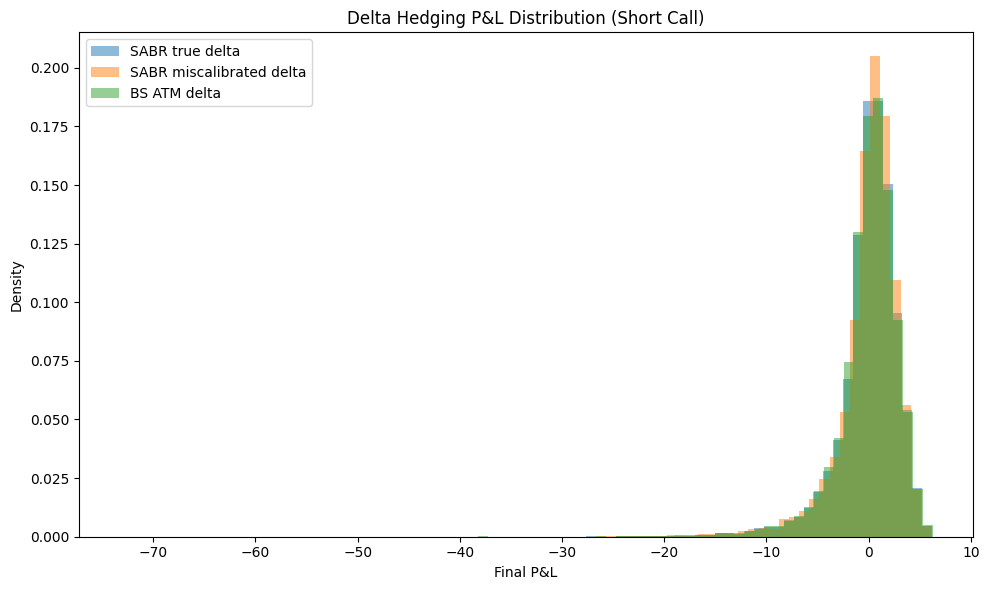

In [122]:
plt.figure(figsize=(10, 6))
plt.hist(pnl_true, bins=80, alpha=0.5, density=True, label="SABR true delta")
plt.hist(pnl_mis, bins=80, alpha=0.5, density=True, label="SABR miscalibrated delta")
plt.hist(pnl_atm, bins=80, alpha=0.5, density=True, label="BS ATM delta")
plt.title("Delta Hedging P&L Distribution (Short Call)")
plt.xlabel("Final P&L")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Visualize SABR Smile Fit

Finally, we compare:
- market Black implied vols extracted from the option chain
- fitted SABR Hagan implied vols

This provides a quick diagnostic for calibration quality.

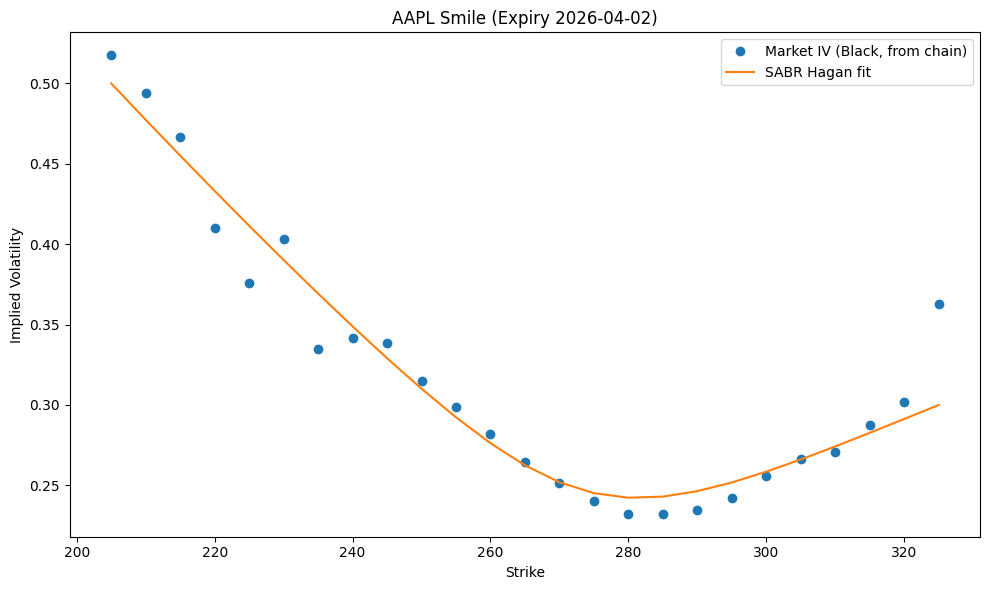

In [123]:
model_iv = np.array(
    [sabr_hagan_lognormal_iv(smile.F0, k, smile.T, alpha_hat, BETA, rho_hat, nu_hat)
     for k in smile.strikes],
    dtype=float
)

plt.figure(figsize=(10, 6))
plt.plot(smile.strikes, smile.iv_black, "o", label="Market IV (Black, from chain)")
plt.plot(smile.strikes, model_iv, "-", label="SABR Hagan fit")
plt.title(f"{SYMBOL} Smile (Expiry {smile.expiry})")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

## 18. Key Takeaways

This project shows that:

1. **SABR can fit the observed volatility smile effectively** using a low-dimensional parameterization.
2. **Delta hedging performance depends strongly on model calibration quality**.
3. A **miscalibrated volatility model can materially worsen hedge dispersion and tail losses**.
4. A simple **Black-Scholes ATM hedge** may be serviceable near the money, but it ignores smile dynamics and can underperform when volatility skew matters.

## Extensions
Potential next steps for further research:
- include dividends in forward construction
- use puts and calls jointly in calibration
- compare local volatility vs SABR hedging
- add transaction costs and discrete rebalancing sensitivity
- estimate hedge Greeks beyond delta (vega / vanna / volga)